In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [8]:
#missing Data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_frequency = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_frequency.fit_transform(titanic[["embarked"]])



In [9]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
titanic.shape

(891, 15)

In [12]:
#Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [13]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [14]:
X = titanic[features]
y = titanic[target]

In [15]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [16]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [19]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [20]:
#Decision Tree Model - No Prunning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [21]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))


Accuracy:  0.770949720670391


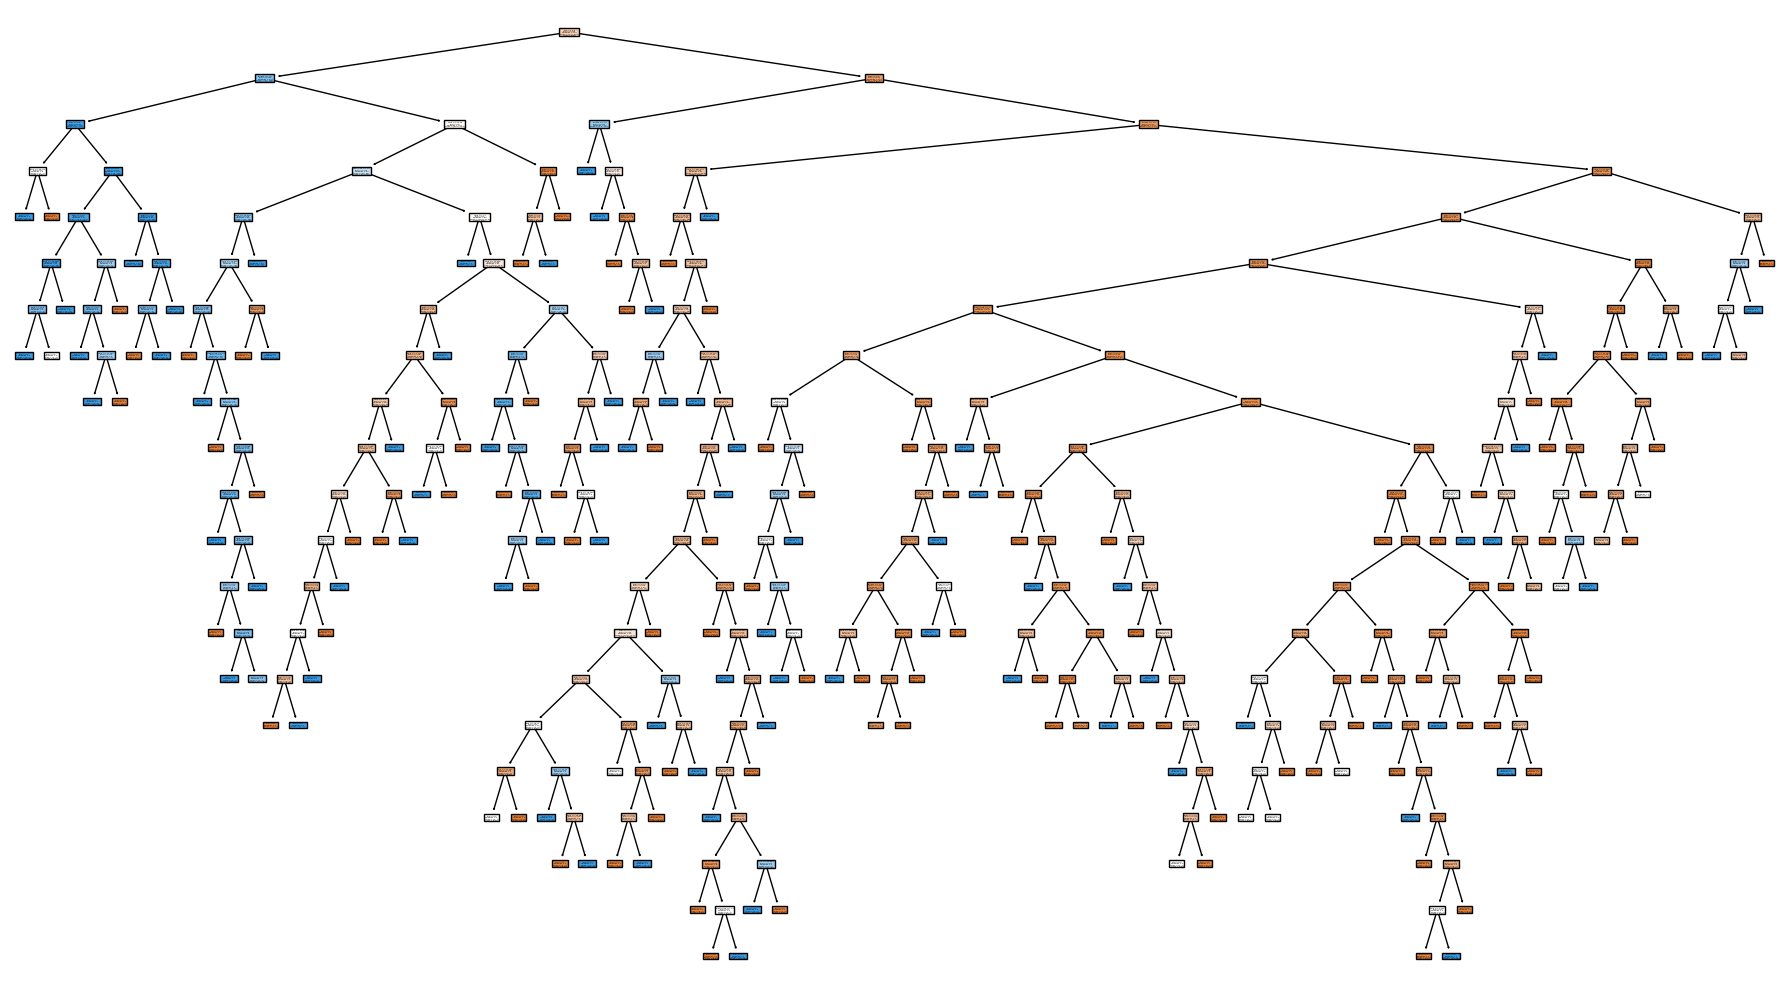

In [22]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,


)

plt.tight_layout()
plt.show()

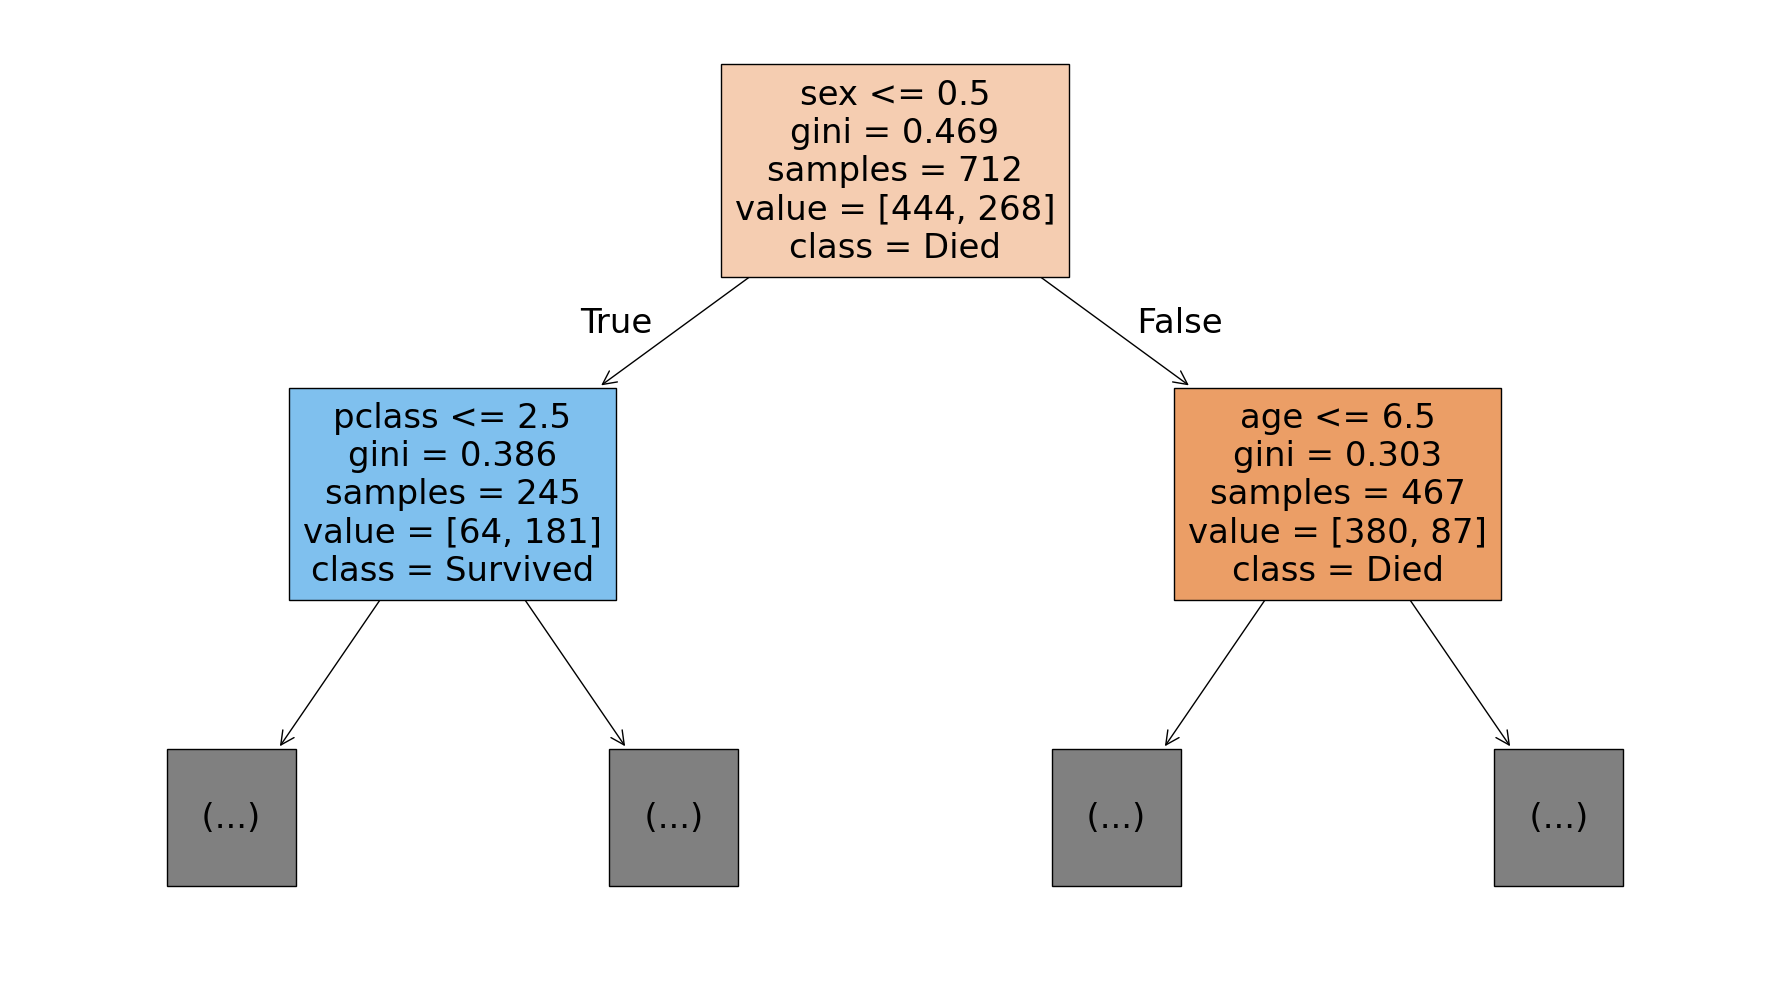

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=1


)

plt.tight_layout()
plt.show()

# Decision Tree With Pre-Prunning

for depth 2 the accuracy is 0.7653631284916201
for depth 3 the accuracy is 0.7988826815642458
for depth 4 the accuracy is 0.7988826815642458
for depth 5 the accuracy is 0.7988826815642458
for depth 6 the accuracy is 0.7988826815642458
for depth 7 the accuracy is 0.7988826815642458
for depth 8 the accuracy is 0.7988826815642458
for depth 9 the accuracy is 0.7877094972067039
for depth 10 the accuracy is 0.7877094972067039


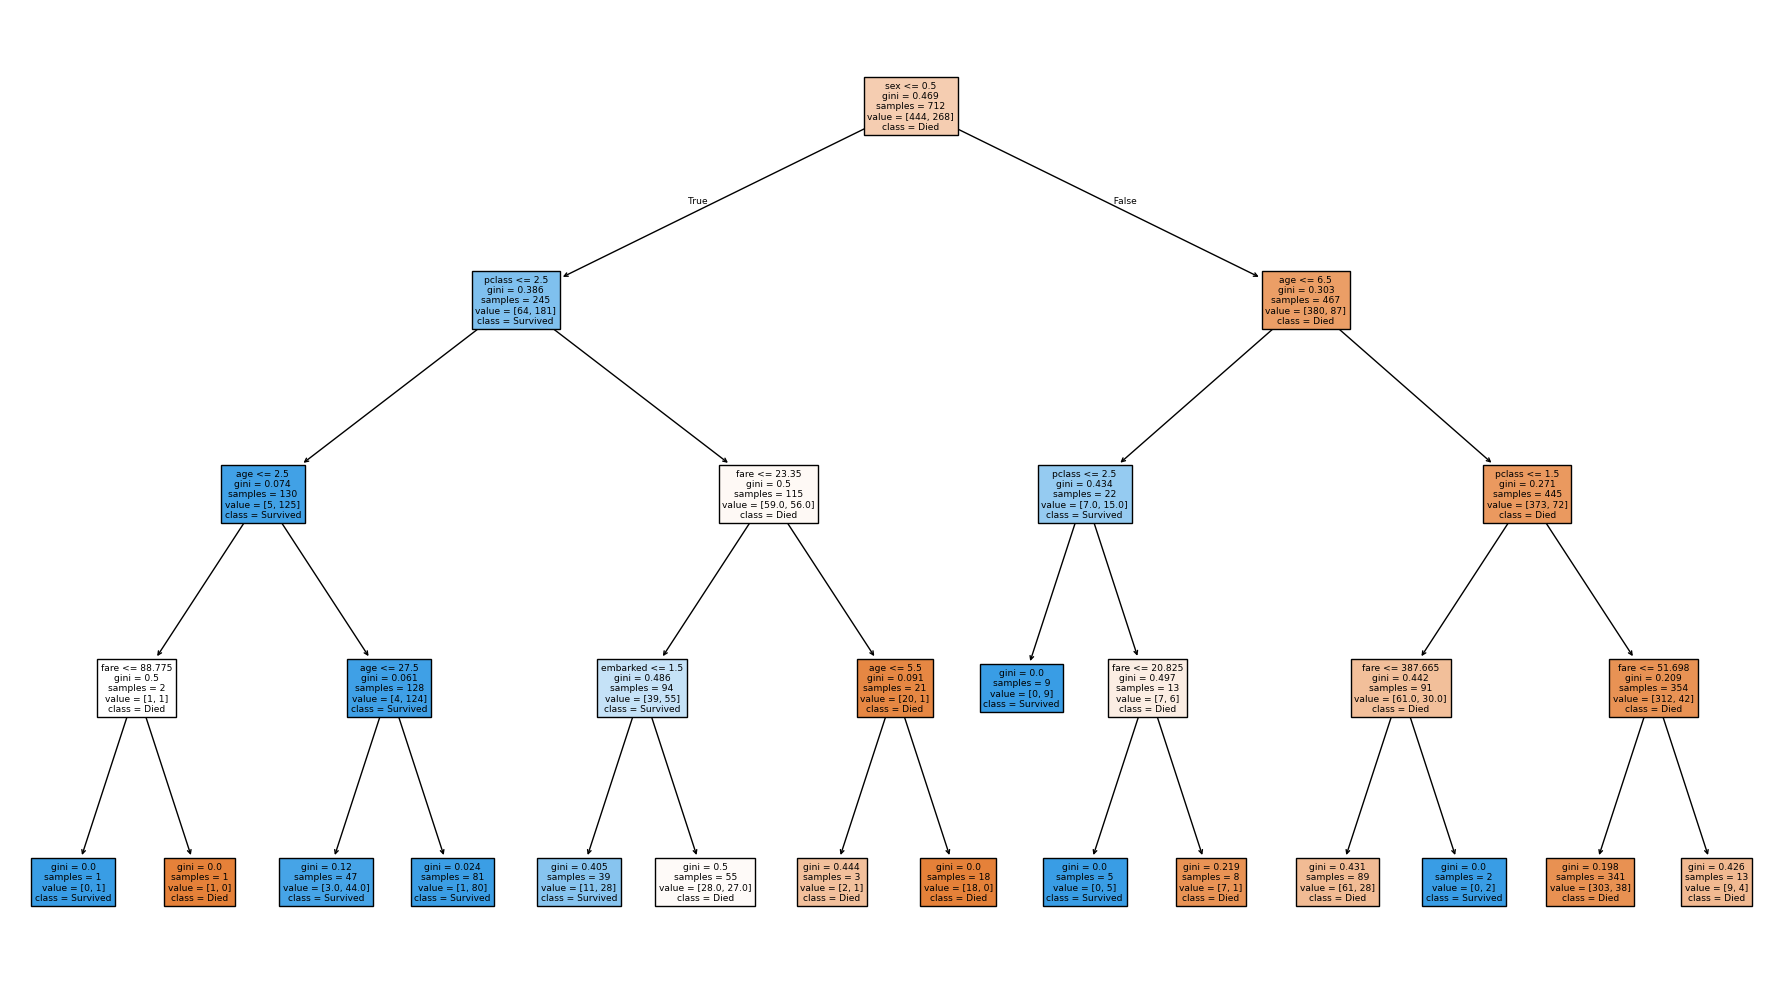

In [24]:
max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    #y_pred = model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"for depth {depth} the accuracy is {acc}")

    if depth == 4:
        plt.figure(figsize=(18, 10))
        plot_tree(
        model,
        feature_names=X.columns,
        class_names=["Died", "Survived"],
        filled=True
        )

plt.tight_layout()
plt.show()



for split 10 the accuracy is 0.7988826815642458
for split 15 the accuracy is 0.7988826815642458
for split 20 the accuracy is 0.7988826815642458
for split 25 the accuracy is 0.7932960893854749
for split 30 the accuracy is 0.7932960893854749


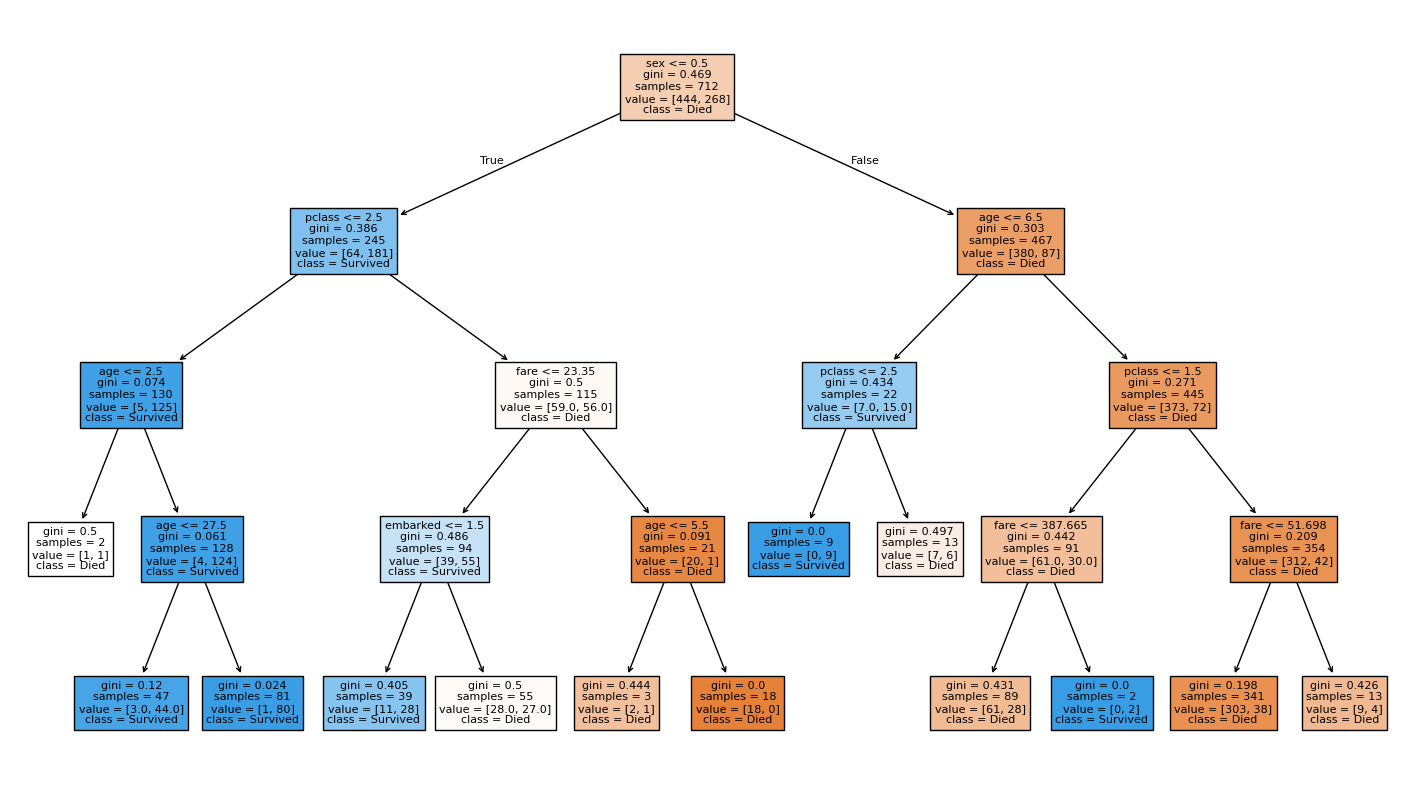

In [25]:
min_samples_split = [10, 15, 20, 25, 30]

for split in min_samples_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    #y_pred = model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"for split {split} the accuracy is {acc}")

    if split == 15:
        plt.figure(figsize=(18, 10))
        plot_tree(
        model,
        feature_names=X.columns,
        class_names=["Died", "Survived"],
        filled=True
        )




In [26]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
ccp_alphas

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
       6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
       8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
       1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
       1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
       1.56675436e-03, 1.60434338e-03, 1.66892062e-03, 1.76144762e-03,
      

In [29]:
#train our model for all alphas
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
   

    trees.append((model, alpha))

In [30]:
best_acc = 0
best_alpha = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [31]:
best_alpha

np.float64(0.0015407231242023183)

In [32]:
best_acc

0.8379888268156425

In [33]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183))

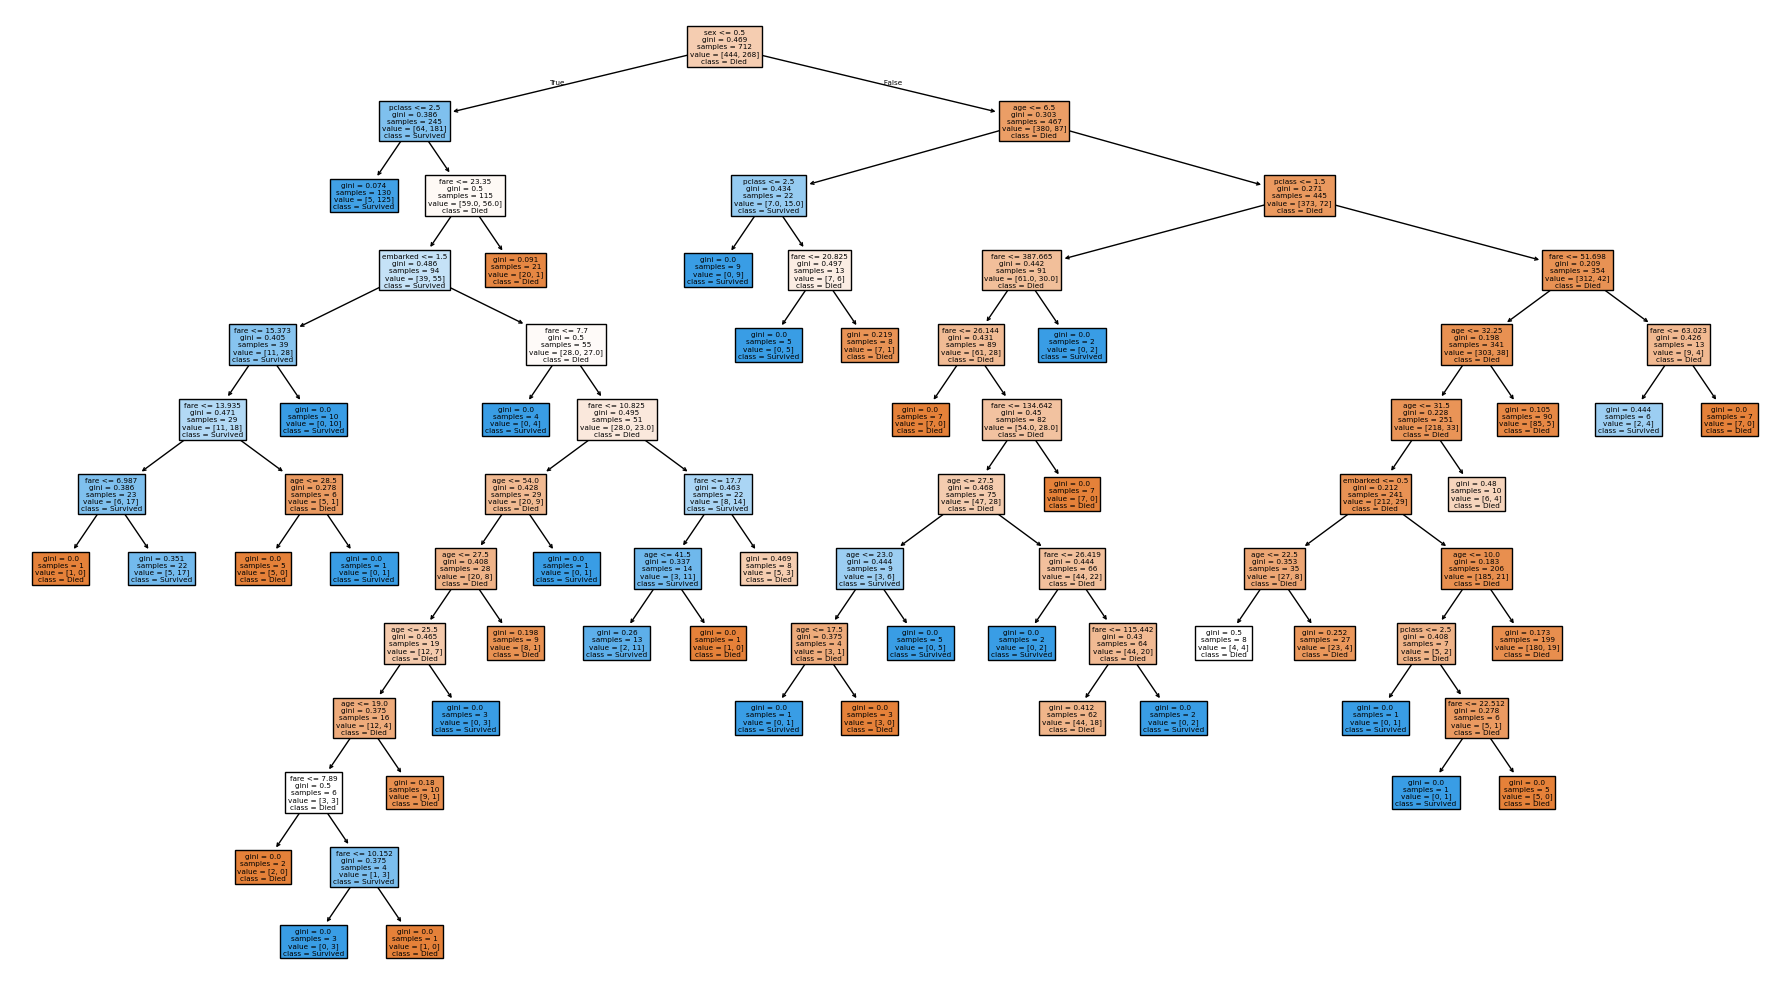

In [34]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [36]:
best_model.score(X_test, y_test)

0.8379888268156425

# Combination of Pre and Post Prunning

In [43]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4, min_samples_split=15)
best_model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0015407231242023183), max_depth=4,
                       min_samples_split=15)

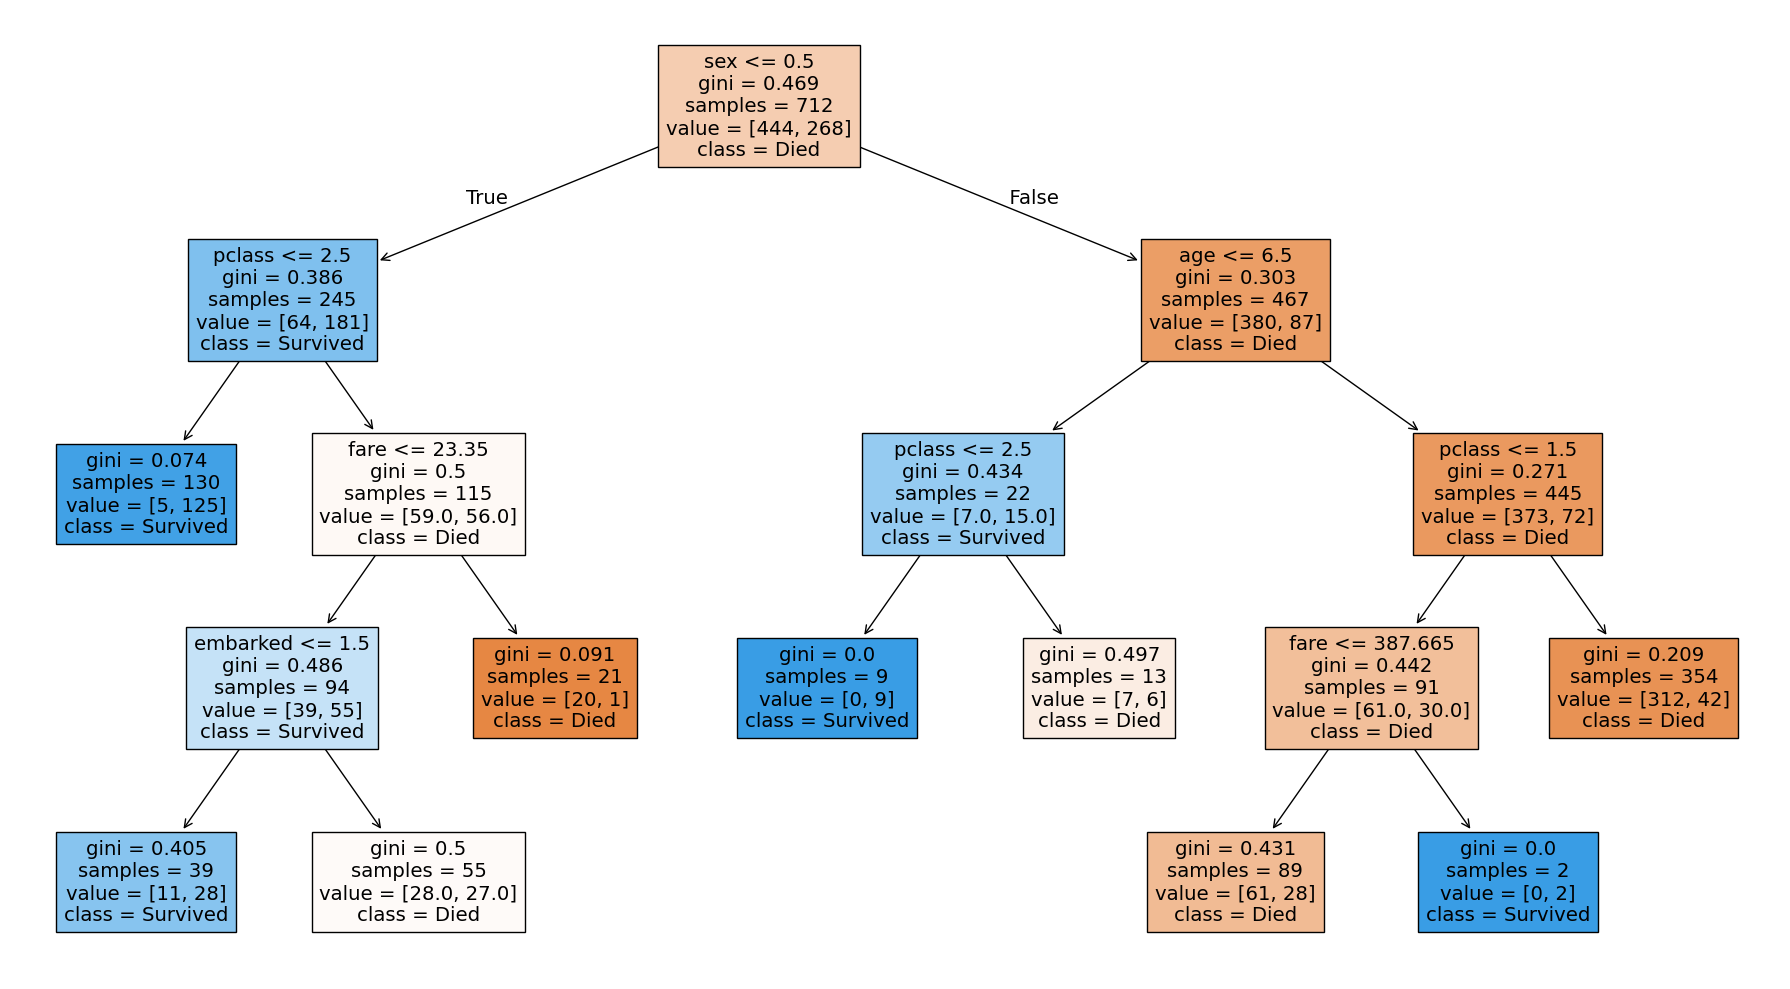

In [44]:
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [45]:
best_model.score(X_test, y_test)

0.7988826815642458

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Make a list of the parameters we want to test together
param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 10, 15, 20],
    'ccp_alpha': [0.0, 0.005, 0.01, 0.05, 0.1]
}

# 2. Create a fresh, blank Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# 3. Set up Grid Search to test all combinations using 5 "Practice Exams" (cv=5)
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='accuracy')

# 4. Train it using ONLY the Training Data! (No peeking at X_test)
print("Testing all combinations... this might take a few seconds.")
grid_search.fit(X_train, y_train)

# 5. Extract the absolute best model from the search
best_combined_model = grid_search.best_estimator_

# 6. Show the winning combination
print("Best Parameters found:", grid_search.best_params_)

# 7. Finally, test this winning model on the unseen Test Data (The Final Exam)
final_accuracy = best_combined_model.score(X_test, y_test)
print(f"True Test Accuracy: {final_accuracy:.4f}")

Testing all combinations... this might take a few seconds.
Best Parameters found: {'ccp_alpha': 0.005, 'max_depth': 3, 'min_samples_split': 2}
True Test Accuracy: 0.7933


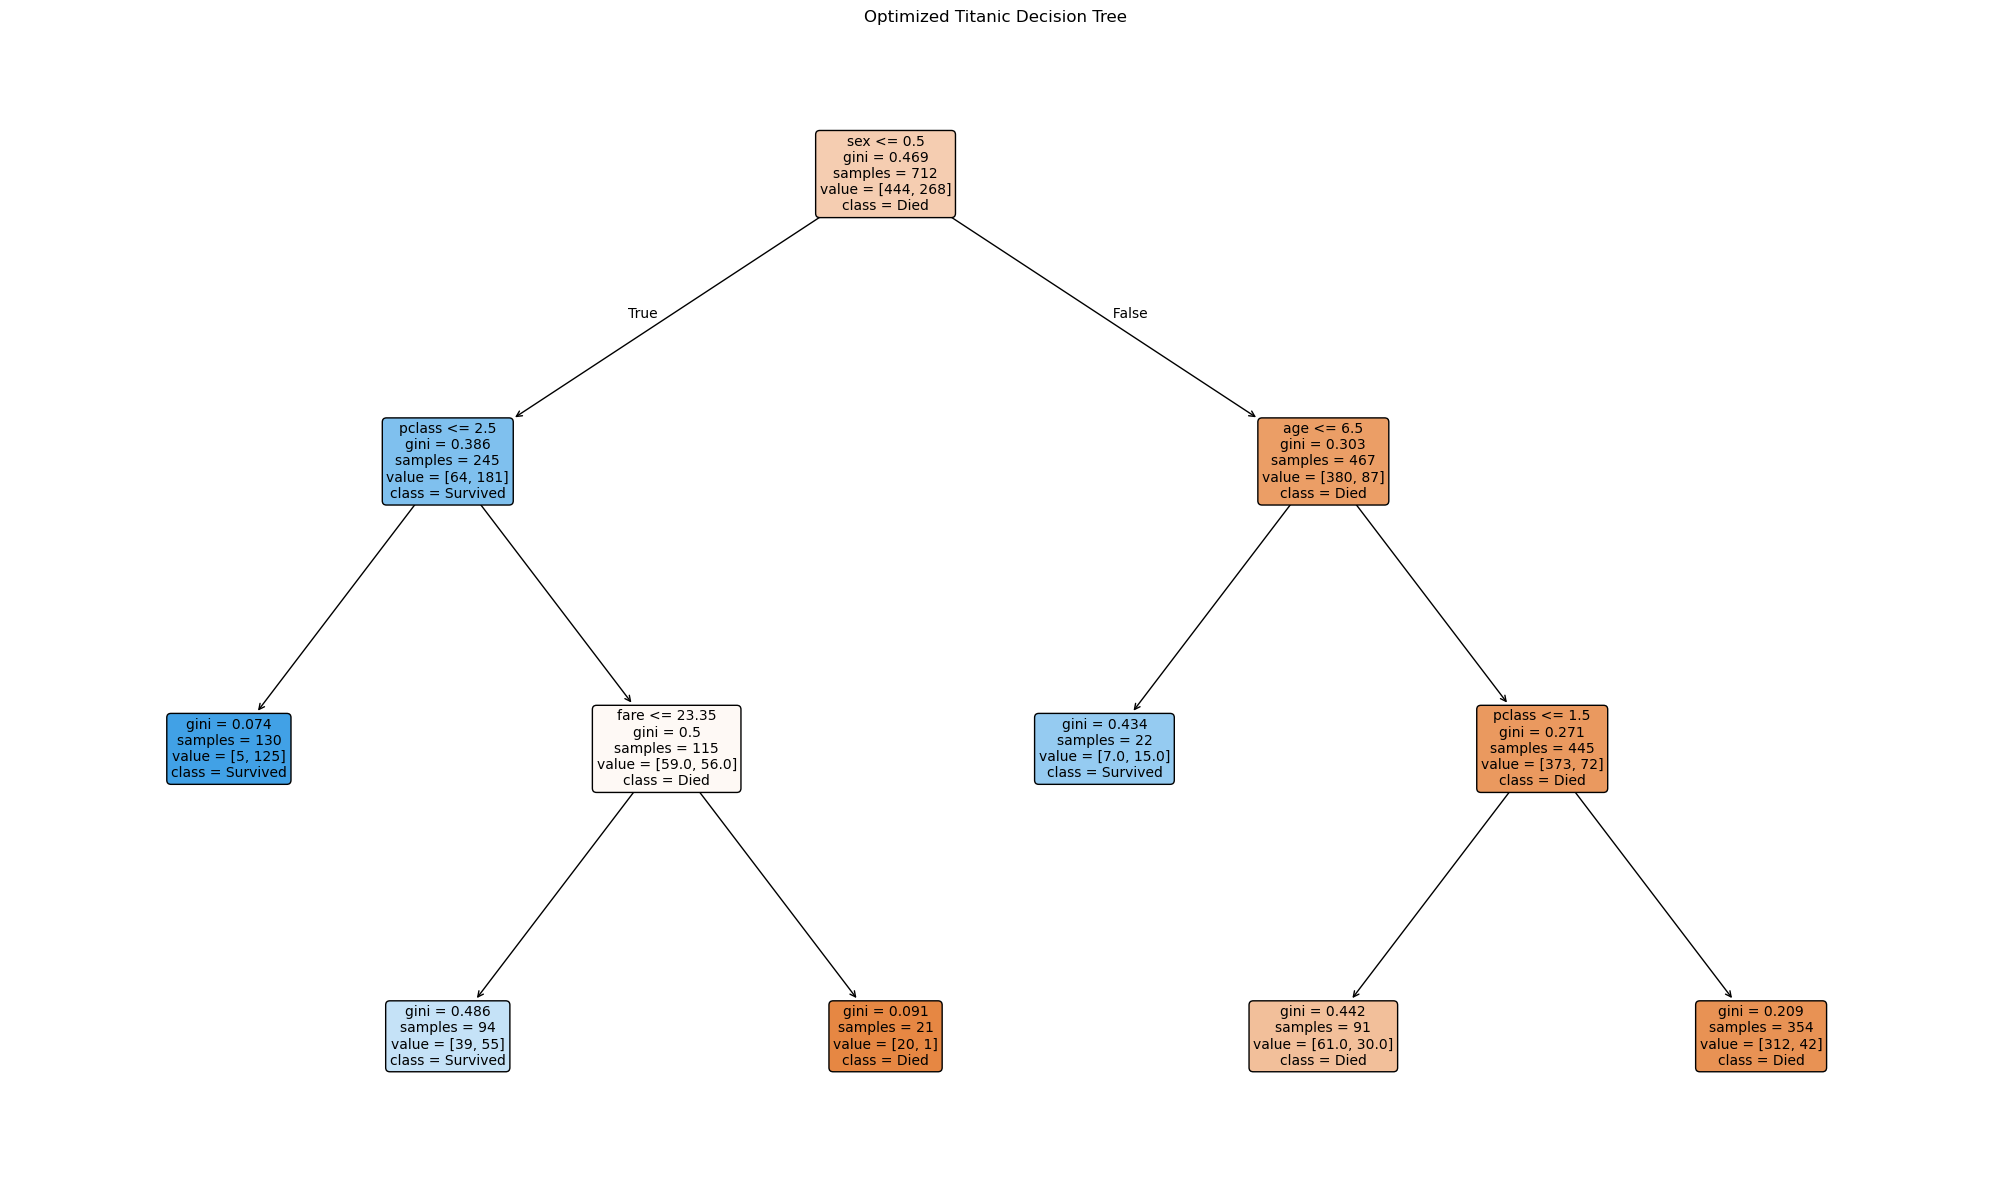

In [47]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Make the plot large enough to read easily
plt.figure(figsize=(20, 12))

# Plot the winning model from our Grid Search
plot_tree(
    best_combined_model, 
    feature_names=X.columns, 
    class_names=["Died", "Survived"], 
    filled=True, 
    rounded=True, 
    fontsize=10
)

plt.title("Optimized Titanic Decision Tree")
plt.tight_layout()
plt.show()

In [48]:
# This is the average accuracy across 5 different, unseen slices of data
print(f"Honest Cross-Validation Score: {grid_search.best_score_:.4f}")

Honest Cross-Validation Score: 0.8146
